import important libraries

In [30]:
import numpy as np
from scipy.signal import welch
import matplotlib.pyplot as plt

In [35]:
# Load the saved data
data = np.load("raw_eye_data.npz")
X = data["X"]
y = data["y"]

# Check the shapes of the loaded data
print("X shape:", X.shape)
print("y shape:", y.shape)

fs = 250

X shape: (1666, 8, 250)
y shape: (1666,)


PSD (Power Spectral Density Analysis)

Open PSD count : 6960
Closed PSD count: 6368


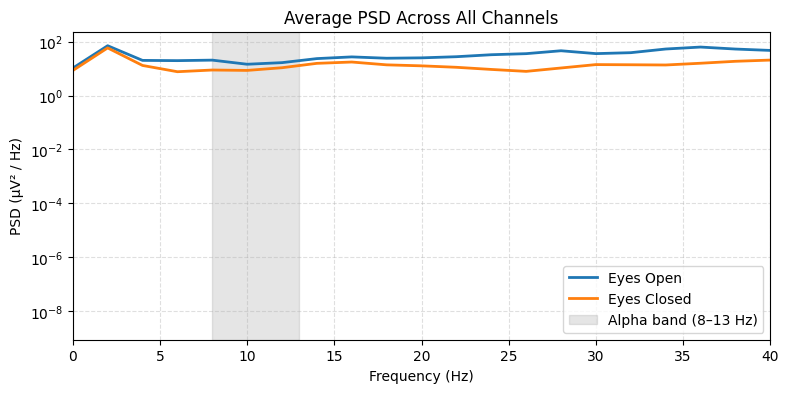

In [36]:
psd_open = []
psd_closed = []

for i in range(len(X)):
    for ch in range(X.shape[1]):
        signal = X[i][ch]  # (250,)
        f, pxx = welch(signal, fs=fs, nperseg=fs // 2)

        if y[i] == 1:      # Eyes open
            psd_open.append(pxx)
        elif y[i] == 2:    # Eyes closed
            psd_closed.append(pxx)

psd_open = np.array(psd_open)
psd_closed = np.array(psd_closed)

print("Open PSD count :", psd_open.shape[0])
print("Closed PSD count:", psd_closed.shape[0])

# --------------------------------------------------
# Average PSDs
# --------------------------------------------------
mean_psd_open = psd_open.mean(axis=0)
mean_psd_closed = psd_closed.mean(axis=0)

# --------------------------------------------------
# Plot
# --------------------------------------------------
plt.figure(figsize=(9, 4))

plt.semilogy(f, mean_psd_open, label="Eyes Open", linewidth=2)
plt.semilogy(f, mean_psd_closed, label="Eyes Closed", linewidth=2)

# Highlight alpha band
plt.axvspan(8, 13, color="gray", alpha=0.2, label="Alpha band (8–13 Hz)")

plt.xlim(0, 40)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (µV² / Hz)")
plt.title("Average PSD Across All Channels")
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.4)

plt.show()

In [42]:
def extract_band_powers(signal, fs=250):
    f, pxx = welch(signal, fs=fs, nperseg=fs//2)

    delta_idx = (f >= 1) & (f <= 4)
    theta_idx = (f >= 4) & (f <= 8)
    alpha_idx = (f >= 8) & (f <= 13)
    beta_idx  = (f >= 13) & (f <= 30)

    delta = np.trapezoid(pxx[delta_idx], f[delta_idx])
    theta = np.trapezoid(pxx[theta_idx], f[theta_idx])
    alpha = np.trapezoid(pxx[alpha_idx], f[alpha_idx])
    beta  = np.trapezoid(pxx[beta_idx],  f[beta_idx])

    var = np.var(signal)

    return (
        np.log(delta + 1e-10),
        np.log(theta + 1e-10),
        np.log(alpha + 1e-10),
        np.log(beta  + 1e-10),
        np.log(var   + 1e-10),
    )

In [44]:
new_X = []
for i in range (len(X)):
    features = []
    for ch in range(X.shape[1]):
        signal = X[i][ch]
        features.extend(extract_band_powers(signal, fs))
    new_X.append(features)

new_X = np.array(new_X)
print("New feature shape:", new_X.shape)

np.savez(
    "processed_eye_data.npz",
    X=new_X,
    y=y,
    fs=fs,
    feature_order=["delta", "theta", "alpha", "beta", "var"]
)

New feature shape: (1666, 40)
